<a href="https://colab.research.google.com/github/AbhiV9/Stroke-Risk-Prevention-using-SHAP-Interpretability/blob/main/Stroke_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing the Pandas
import pandas as pd

In [ ]:
  # Loading the dataset. Downloading the csv file
from google.colab import files
uploaded = files.upload()

# Dataframe is a 2 dimensional labeled data structure
# Assume the file that is uploaded is the same name as below
df = pd.read_csv('healthcare-dataset-stroke-data.csv')


Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data (1).csv


In [ ]:
#Printing the data frame
print(df)

         id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban             228.69  36.6  former

In [ ]:
# Drop the ID column
#axis = 1 means column while axis = 0 means row
df.drop('id', axis = 1, inplace = True)

In [ ]:
# Data Types
print("\n🧠 Data Types:")
print(df.dtypes)


🧠 Data Types:
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [ ]:
# Missing Values
print("\n❓Missing Values:")
print(df.isnull().sum())


❓Missing Values:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [ ]:
# Descriptive Statistics
# df.describe() gives you count, mean standard deviation, min, 25%, 75%, median, and max
print("\n📊 Descriptive Statistics: ")
print(df.describe(include='all').transpose())


📊 Descriptive Statistics: 
                    count unique           top  freq        mean        std  \
gender               5110      3        Female  2994         NaN        NaN   
age                5110.0    NaN           NaN   NaN   43.226614  22.612647   
hypertension       5110.0    NaN           NaN   NaN    0.097456   0.296607   
heart_disease      5110.0    NaN           NaN   NaN    0.054012   0.226063   
ever_married         5110      2           Yes  3353         NaN        NaN   
work_type            5110      5       Private  2925         NaN        NaN   
Residence_type       5110      2         Urban  2596         NaN        NaN   
avg_glucose_level  5110.0    NaN           NaN   NaN  106.147677   45.28356   
bmi                4909.0    NaN           NaN   NaN   28.893237   7.854067   
smoking_status       5110      4  never smoked  1892         NaN        NaN   
stroke             5110.0    NaN           NaN   NaN    0.048728    0.21532   

                     mi

In [ ]:
# Data Cleaning

# Fills out the missing BMI with the median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [ ]:
# Data Manipulation

# Replace rare gender category
print('Before replacing the "Other" in the gender column: ')
print(df['gender'].value_counts())

df['gender'] = df['gender'].replace('Other', 'Male')

print('\nAfter replacing "Other" with Male: ')
print(df['gender'].value_counts())

Before replacing the "Other" in the gender column: 
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

After replacing "Other" with Male: 
gender
Female    2994
Male      2116
Name: count, dtype: int64


In [ ]:
# Binary Encoding
df["gender"] = df['gender'].map({'Male': 0, 'Female' : 1})
df['ever_married'] = df['ever_married'].map({'No': 0, 'Yes' : 1})
df['Residence_type'] = df['Residence_type'].map({'Rural' : 0, 'Urban' : 1})

In [ ]:
print('\nAfter Binary Encoding:')
print(df[['gender', 'ever_married', 'Residence_type']].head())


After Binary Encoding:
   gender  ever_married  Residence_type
0       0             1               1
1       1             1               0
2       0             1               0
3       1             1               1
4       1             1               0


In [ ]:
# One hot encoding
# Show the original categorical columns before one hot
print('\nUnique values in "work_type" and "smoking_status" before encoding:')
print('work_type:', df['work_type'].unique())
print('smoking_status:', df['work_type'].unique())

#One hot encoding 'work_type' and 'smoking_status'
df = pd.get_dummies(df, columns = ['work_type', 'smoking_status'], drop_first=True)

# Show new columns created
print('\nColumns after one-hot encoding:')
print(df.columns.tolist())


Unique values in "work_type" and "smoking_status" before encoding:
work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
smoking_status: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Columns after one-hot encoding:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


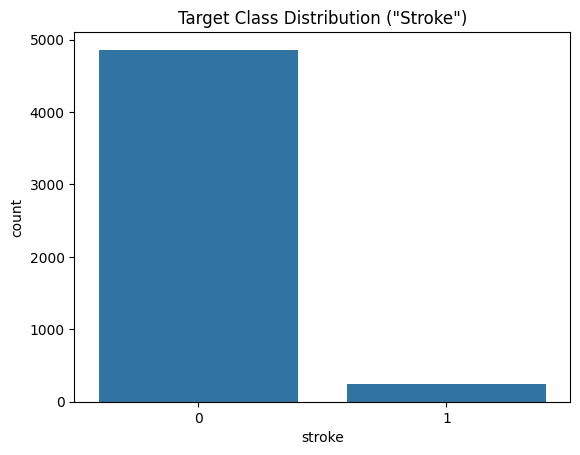

In [ ]:
# Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Class imbalance
sns.countplot(x = 'stroke', data=df)
plt.title('Target Class Distribution ("Stroke")')
plt.show()

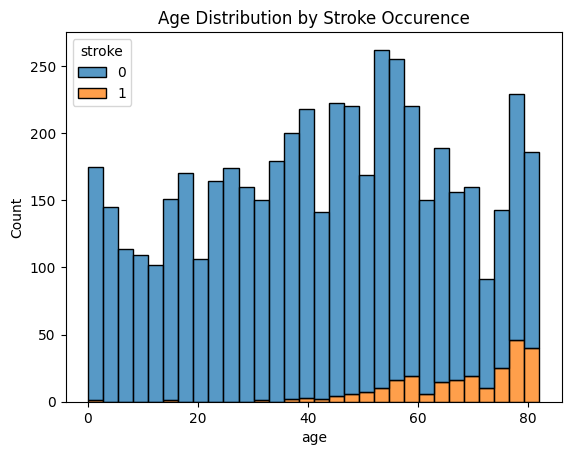

In [ ]:
# Age Distribution by stroke
sns.histplot(data=df, x='age', hue='stroke', multiple='stack', bins=30)
plt.title('Age Distribution by Stroke Occurence')
plt.show()

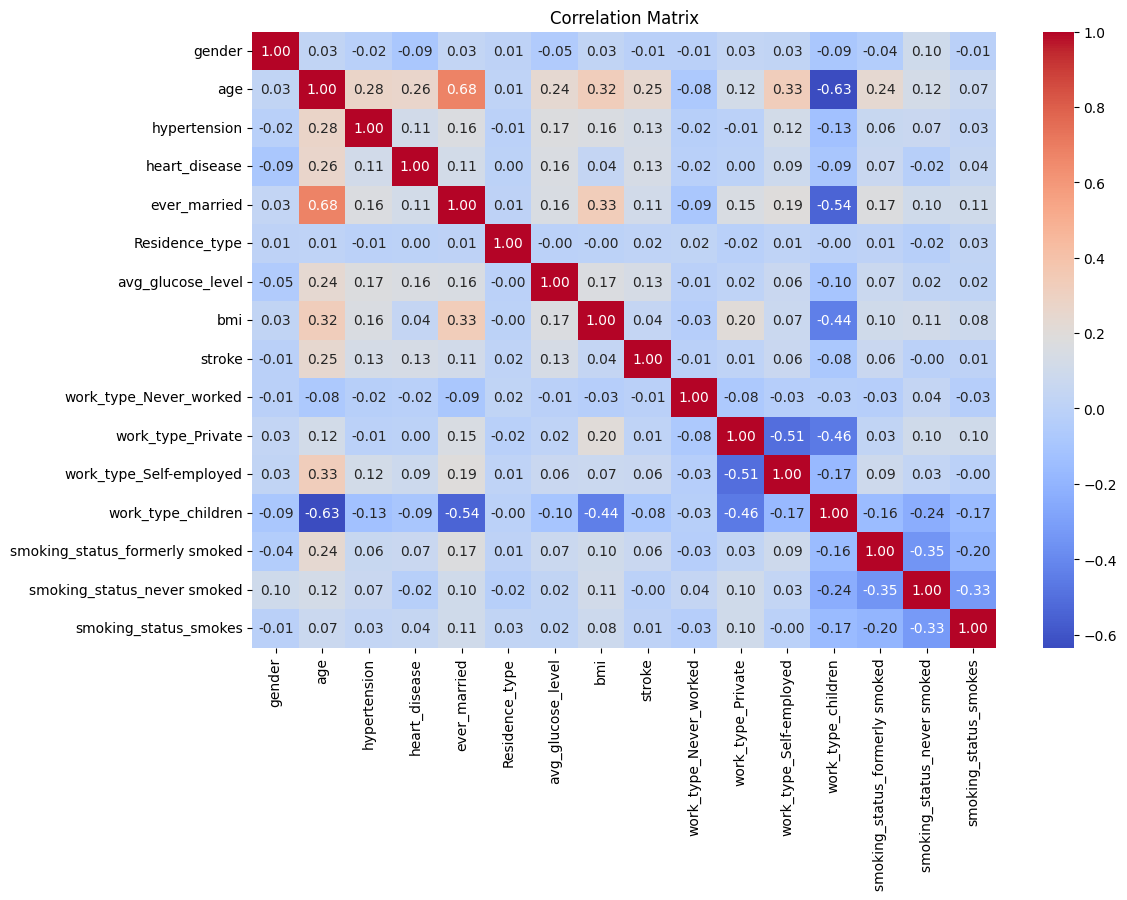

In [ ]:
# Correlation Heat Map
plt.figure(figsize = (12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
import sklearn as sk

from sklearn.model_selection import train_test_split

# Creating a features data set with all the calues except stroke
x = df.drop('stroke', axis = 1)

# Creating a label data set with the stroke values
y = df['stroke']

# Creates a training and testing data set
# This is to tech the model and then later testing to see if it learned
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# How much datat is being used to train the machine
print("X_train shape:", X_train.shape)

# How much data is being used to test the machines knowledge
print("X_test shape :", X_test.shape)

X_train shape: (4088, 15)
X_test shape : (1022, 15)


In [ ]:
print("Stroke value counts in y_train:")
print(y_train.value_counts())

print("Stroke value counts in y_test:")
print(y_test.value_counts())

Stroke value counts in y_train:
stroke
0    3889
1     199
Name: count, dtype: int64
Stroke value counts in y_test:
stroke
0    972
1     50
Name: count, dtype: int64


In [ ]:
print("Feature names:")
print(x.columns.tolist())

Feature names:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scales the training data set
X_train_scaled = scaler.fit_transform(X_train)

# Scales the testing data set
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled)
print('\nMarker')
print(X_test_scaled)

[[ 0.84076712  0.20566087 -0.32796178 ... -0.46001984  1.31282811
  -0.42522974]
 [-1.18938999 -1.25490055 -0.32796178 ... -0.46001984  1.31282811
  -0.42522974]
 [ 0.84076712  1.04659017 -0.32796178 ... -0.46001984  1.31282811
  -0.42522974]
 ...
 [ 0.84076712  0.78103355 -0.32796178 ...  2.17381926 -0.76171434
  -0.42522974]
 [-1.18938999 -0.54674956 -0.32796178 ... -0.46001984 -0.76171434
  -0.42522974]
 [ 0.84076712 -1.65323548 -0.32796178 ... -0.46001984 -0.76171434
  -0.42522974]]

Marker
[[-1.18938999  0.86955242 -0.32796178 ... -0.46001984  1.31282811
  -0.42522974]
 [ 0.84076712 -0.01563631 -0.32796178 ... -0.46001984  1.31282811
  -0.42522974]
 [ 0.84076712 -0.90082505 -0.32796178 ... -0.46001984 -0.76171434
   2.35166993]
 ...
 [ 0.84076712  0.29417974 -0.32796178 ... -0.46001984  1.31282811
  -0.42522974]
 [-1.18938999 -1.25490055 -0.32796178 ... -0.46001984  1.31282811
  -0.42522974]
 [ 0.84076712  0.33843918 -0.32796178 ...  2.17381926 -0.76171434
  -0.42522974]]


In [ ]:
# Our dataset is imbalanced: only about 5% of samples are stroke cases.
# SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic examples
# of the minority class to help the model learn better.

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Print new class distribution after SMOTE
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE :", pd.Series(y_train_res).value_counts())

Before SMOTE: stroke
0    3889
1     199
Name: count, dtype: int64
After SMOTE : stroke
0    3889
1    3889
Name: count, dtype: int64


In [ ]:
#Import necessary tools
#LogisticRegression: the machine learning model we’ll use. classification_report: shows precision, recall, f1-score, accuracy.
#confusion_matrix: shows how many predictions were right vs wrong

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

#Make the model , iteration = 1000 makes the model run longer.
log_reg = LogisticRegression(max_iter=1000)

#Teach the model by training
log_reg.fit(X_train, y_train)

#Test the model
y_pred = log_reg.predict(X_test)

#See results
print("Logistic Regression Results")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression Results
[[972   0]
 [ 49   1]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



In [ ]:
#Import the decision tree
from sklearn.tree import DecisionTreeClassifier

#Create the model
tree = DecisionTreeClassifier(random_state=42)

#Train the model
tree.fit(X_train, y_train)

#Make predictions
y_pred_tree = tree.predict(X_test)

#See Results
print("Decision Tree Results")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Decision Tree Results
[[922  50]
 [ 39  11]]
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       972
           1       0.18      0.22      0.20        50

    accuracy                           0.91      1022
   macro avg       0.57      0.58      0.58      1022
weighted avg       0.92      0.91      0.92      1022



In [ ]:
#Import the tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

#Create the random forest model
rf = RandomForestClassifier(random_state=42)

#Train the model
rf.fit(X_train, y_train)

#Make preductions
y_pred_rf = rf.predict(X_test)

#See results
print("Random Forest Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
[[970   2]
 [ 50   0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



In [ ]:
# create a new random forest with new weights.
# Normally, the model pays more attention to the majority class (non-stroke) because there are so many more of them.
# With balanced, scikit‑learn automatically gives higher weight to the minority class (stroke).
# This forces the model to “care more” about correctly predicting strokes.

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
# Train on SMOTE‑resampled data
# Combining SMOTE + class_weight='balanced' = double help for the minority class.
rf.fit(X_train_res, y_train_res)
# Predict on the original test set
y_pred_rf = rf.predict(X_test)

In [ ]:
y_probs_rf = rf.predict_proba(X_test)[:,1]
y_pred_rf_thresh = (y_probs_rf >= 0.4).astype(int)
print(confusion_matrix(y_test, y_pred_rf_thresh))
print(classification_report(y_test, y_pred_rf_thresh))

[[902  70]
 [ 40  10]]
              precision    recall  f1-score   support

           0       0.96      0.93      0.94       972
           1       0.12      0.20      0.15        50

    accuracy                           0.89      1022
   macro avg       0.54      0.56      0.55      1022
weighted avg       0.92      0.89      0.90      1022



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predicted probabilities for the positive class (stroke = 1)
y_probs_log = log_reg.predict_proba(X_test)[:,1]

# Choose a lower threshold (e.g., 0.25)
threshold = 0.25
y_pred_log_thresh = (y_probs_log >= threshold).astype(int)

print(f"Logistic Regression Results with threshold = {threshold}")
print(confusion_matrix(y_test, y_pred_log_thresh))
print(classification_report(y_test, y_pred_log_thresh))

Logistic Regression Results with threshold = 0.25
[[946  26]
 [ 42   8]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       972
           1       0.24      0.16      0.19        50

    accuracy                           0.93      1022
   macro avg       0.60      0.57      0.58      1022
weighted avg       0.92      0.93      0.93      1022



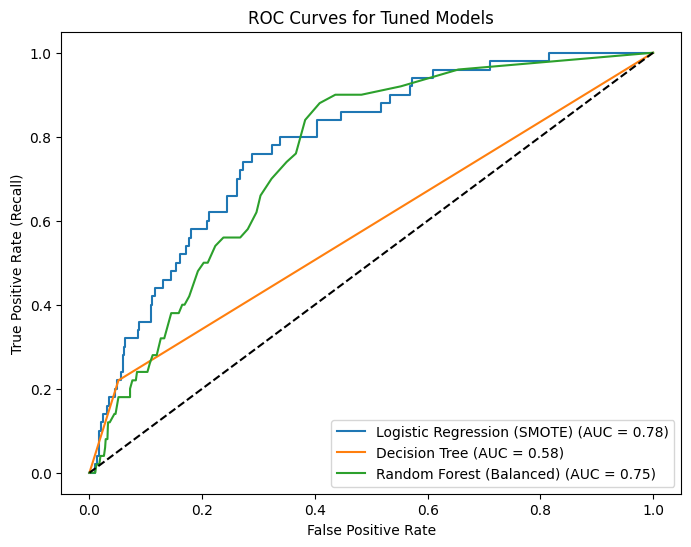

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Retrain Logistic Regression on SMOTE-balanced data
log_reg_res = LogisticRegression(max_iter=1000)
log_reg_res.fit(X_train_res, y_train_res)

# Retrain Random Forest with class weights on SMOTE-balanced data
rf_bal = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_bal.fit(X_train_res, y_train_res)

# Models dictionary now uses tuned models
models = {
    "Logistic Regression (SMOTE)": log_reg_res,
    "Decision Tree": tree,
    "Random Forest (Balanced)": rf_bal
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')  # baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves for Tuned Models')
plt.legend()
plt.show()

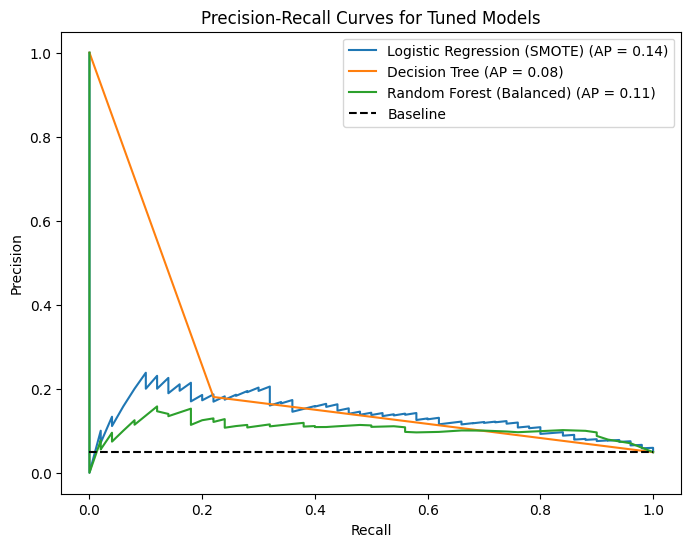

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    avg_prec = average_precision_score(y_test, y_probs)
    plt.plot(recall, precision, label=f"{name} (AP = {avg_prec:.2f})")

# Add baseline
baseline = y_test.mean()
plt.plot([0,1], [baseline, baseline], 'k--', label='Baseline')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Tuned Models')
plt.legend()
plt.show()